**eBay Car Sales Data**

The eBay Kleinanzeigen dataset is messy in the way real data always is: column names in German, outlier prices in the millions, registration years in the future, and inconsistent formatting throughout. Cleaning it properly, and being transparent about your decisions, is the whole project.

*Step-by-Step Instructions:*

1.  Load the data and inspect column names and data types.
2.  Clean column names and convert to snake_case.
3.  Identify and handle outliers in price and mileage.
4.  Explore the relationship between price and brand, mileage, and age.
5.  Calculate mean prices by brand and identify which brands hold value best.

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sijovm/used-cars-data-from-ebay-kleinanzeigen")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'used-cars-data-from-ebay-kleinanzeigen' dataset.
Path to dataset files: /kaggle/input/used-cars-data-from-ebay-kleinanzeigen


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

1.

In [53]:
df = pd.read_csv('autos.csv', encoding='Latin-1')
df

,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,powerPS,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21


In [54]:
print(os.getcwd())
print(os.listdir('.'))

/content
['.config', 'autos.csv', 'sample_data']


2.

In [58]:
df_cols = df.columns.tolist()
df_cols

['dateCrawled',
 'name',
 'seller',
 'offerType',
 'price',
 'abtest',
 'vehicleType',
 'yearOfRegistration',
 'gearbox',
 'powerPS',
 'model',
 'kilometer',
 'monthOfRegistration',
 'fuelType',
 'brand',
 'notRepairedDamage',
 'dateCreated',
 'nrOfPictures',
 'postalCode',
 'lastSeen']

In [59]:
def to_snake_case(name):
  a = []
  for i in df_cols:
    i = str(i).strip()
    i = re.sub(r'([a-z0-9])([A-Z])', r'\1_\2', i)
    a.append('_'.join(i.lower().split()))
  return a

In [65]:
new_cols = to_snake_case(df_cols)

In [72]:
len(df.columns.tolist())

20

In [79]:
df.columns = new_cols
df

,date_crawled,name,seller,offer_type,price,abtest,vehicle_type,year_of_registration,gearbox,power_ps,model,kilometer,month_of_registration,fuel_type,brand,not_repaired_damage,date_created,nr_of_pictures,postal_code,last_seen
0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,0,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,190,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,163,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,75,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,69,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371523,2016-03-14 17:48:27,Suche_t4___vito_ab_6_sitze,privat,Angebot,2200,test,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14 00:00:00,0,39576,2016-04-06 00:46:52
371524,2016-03-05 19:56:21,Smart_smart_leistungssteigerung_100ps,privat,Angebot,1199,test,cabrio,2000,automatik,101,fortwo,125000,3,benzin,smart,nein,2016-03-05 00:00:00,0,26135,2016-03-11 18:17:12
371525,2016-03-19 18:57:12,Volkswagen_Multivan_T4_TDI_7DC_UY2,privat,Angebot,9200,test,bus,1996,manuell,102,transporter,150000,3,diesel,volkswagen,nein,2016-03-19 00:00:00,0,87439,2016-04-07 07:15:26
371526,2016-03-20 19:41:08,VW_Golf_Kombi_1_9l_TDI,privat,Angebot,3400,test,kombi,2002,manuell,100,golf,150000,6,diesel,volkswagen,NaN,2016-03-20 00:00:00,0,40764,2016-03-24 12:45:21


3.

In [83]:
df[['kilometer','price']].dtypes

,0
kilometer,int64
price,int64


In [85]:
df['price'].describe()

,price
count,3.715280e+05
mean,1.729514e+04
std,3.587954e+06
min,0.000000e+00
25%,1.150000e+03
50%,2.950000e+03
75%,7.200000e+03
max,2.147484e+09


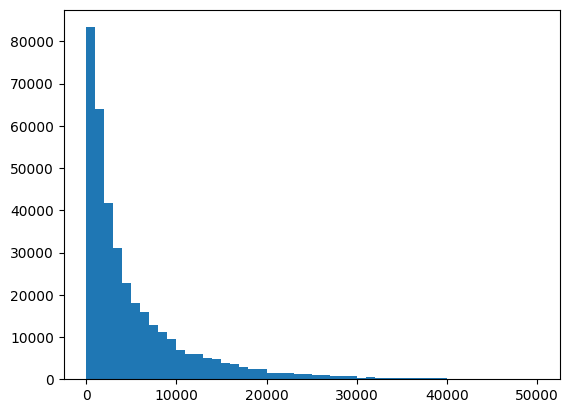

In [91]:
x = df['price'].to_numpy()
plt.hist(x, bins=50, range=(0, 50_000))
plt.show()


<Axes: >

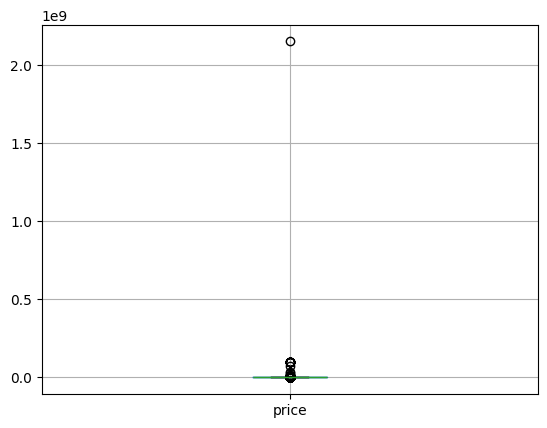

In [95]:
df[['price']].boxplot()

In [125]:
a = df['price'].value_counts().sort_values(ascending = False)
a.head(5)

,count
price,
0,10778
500,5670
1500,5394
1000,4649
1200,4594


In [126]:
a.tail(5)

,count
price,
2825,1
2828,1
2833,1
2846,1
1605,1


In [135]:
df[df['price'] == 1].size

23780

In [136]:
low = df.loc[df['price'].between(0, 300), 'price'].value_counts().sort_index()
print(low.head(30))

price
0     10778
1      1189
2        12
3         8
4         1
5        26
7         3
8         9
9         8
10       84
11        5
12        8
13        7
14        5
15       27
16        2
17        5
18        3
19        3
20       51
21        1
24        1
25       33
26        1
27        1
29        2
30       55
32        1
33        1
35       18
Name: count, dtype: int64


In [137]:
top = df.sort_values('price', ascending=False)[['name', 'price']]
print(top.head(40))

                                                     name       price
371527       BMW_M135i_vollausgestattet_NP_52.720____Euro  2147483647
371516                                Volkswagen_Lupo_1.0    99999999
371525                 Volkswagen_Multivan_T4_TDI_7DC_UY2    99999999
371515                              Skoda_Fabia_Kombi_1.4    99999999
371518                          Bmw_320_D_DPF_Touring_!!!    99999999
371517                   Volkswagen_Golf_2.0_TDI_DPF_Team    99999999
371523                         Suche_t4___vito_ab_6_sitze    99999999
371522                                    Mitsubishi_Cold    99999999
371521                 Opel_Zafira_1.6_Elegance_TÜV_12/16    99999999
371520                                       turbo_defekt    99999999
371519  Alfa_Romeo_159_Jtdm_1.9_150_ps_13_600_km_top_voll    99999999
371524              Smart_smart_leistungssteigerung_100ps    99999999
371512                 Mercedes_Benz_E_400_CDI_Avantgarde    99999999
371514              

In [138]:
mid = df[df['price'].between(50_000, 1_000_000)].sort_values('price')[['name', 'price']]
print(len(mid))
print(mid.to_string())

1517
                                                                       name    price
369946                                       Opel_Zafira_1.8_N_Joy_7_Sitzer    50000
369954                                                              Audi_A3    50000
369955                                                         VW_Golf_3_CL    50000
369956    Volkswagen_Passat_Variant_2.0_TDI_DPF_DSG_Highline_Xenon_T_O_P***    50000
369957                                                Mercedes_Benz_GLK_200    50000
369958                        Clubraum_gesucht_!!_Scheune_Halle_Zimmer_etc.    50000
369962          Kia_Sportage__Spirit_Vollausstattung_mit_57_Monate_Garantie    50000
369961                                                    Volkswagen_Beetle    50000
369963                                         Peugeot_306_mit_frischen_TÜV    50000
369964        AUDI_80____EZ:_1992_/_200.000_km_/_90_PS_/_TÜV:_bis_10/2017__    50000
369949          Volkswagen_Caddy_1.6TDI_Maxi_Comf._Navi_Stan

In [139]:
n_before = len(df)
df = df[df['price'].between(100, 150_000)].copy()
removed = n_before - len(df)
print(f"حذف‌شده: {removed} از {n_before} ({removed / n_before:.2%})")
print(df['price'].describe())

حذف‌شده: 13552 از 371528 (3.65%)
count    357976.000000
mean       5871.727971
std        7978.930434
min         100.000000
25%        1290.000000
50%        3100.000000
75%        7500.000000
max      150000.000000
Name: price, dtype: float64


In [140]:
print(df[df['price'] > 80_000].sort_values('price')[['name', 'price']].to_string())

                                                                     name   price
370948                                        Peugeot_3008_HDi_115_Allure   80900
370949                                     VW_Sharan_Diesel_1_9Tdi_Cruise   80900
370950                           Ford_S_Max_2.0_TDCi_DPF_Titanium_7_Sitze   80900
370951                                        Sehr_gepflegter_Fiesta_2007   81000
370952                                                       Renault_Clip   81000
370953        Volkswagen_Tiguan_2.0_TDI_DPF_BlueMotion_Technology_Sport_&   81500
370954                                                     Peugeot_307_sw   81500
370955                               Peugeot_407_SW_HDi_110_Business_Line   81900
370956                                                         Fiat_Stilo   82000
370957                                    Audi_A6_Avant_1.8_T_Mit_LPG_Gas   82500
370958                              Volkswagen_Golf_1.9_TDI_Sport_Edition   82500
370959          

In [141]:
print(df['kilometer'].describe())
print(df['kilometer'].value_counts().sort_index())

count    357976.000000
mean     125621.550048
std       40109.501807
min        5000.000000
25%      125000.000000
50%      150000.000000
75%      150000.000000
max      150000.000000
Name: kilometer, dtype: float64
kilometer
5000        6815
10000       1878
20000       5469
30000       5800
40000       6146
50000       7346
60000       8373
70000       9370
80000      10642
90000      12094
100000     15358
125000     36661
150000    232024
Name: count, dtype: int64


4.

In [143]:
df['year_of_registration'].describe()

,year_of_registration
count,357976.000000
mean,2004.618500
std,94.584624
min,1000.000000
25%,1999.000000
50%,2003.000000
75%,2008.000000
max,9999.000000


In [145]:
n_before = len(df)
df = df[df['year_of_registration'].between(1950, 2016)].copy()
removed = n_before - len(df)

In [146]:
df['year_of_registration'].describe()

,year_of_registration
count,343587.000000
mean,2002.821469
std,7.132815
min,1950.000000
25%,1999.000000
50%,2003.000000
75%,2008.000000
max,2016.000000


In [148]:
df['age'] = 2016 - df['year_of_registration']

                count         mean  median
brand                                     
kia              2361  6298.507412  3100.0
alfa_romeo       2184  6157.248626  3394.5
skoda            5255  6106.441104  3200.0
chrysler         1356  6091.331121  2999.0
nissan           4652  6071.786758  3200.0
sonstige_autos   3593  5978.807960  2999.0
honda            2602  5932.500769  3292.5
seat             6370  5932.312716  3000.0
renault         16329  5917.458203  3000.0
opel            36851  5913.864698  3100.0
dacia             845  5913.280473  3100.0
smart            4850  5912.822887  3150.0
audi            30712  5905.113864  3100.0
toyota           4401  5899.167007  3200.0
mitsubishi       2846  5897.503162  3200.0
peugeot         10247  5891.521518  3100.0
volkswagen      73130  5862.503391  3100.0
daihatsu          750  5854.085333  3000.0
ford            23621  5844.007790  3100.0
citroen          4756  5835.926198  2999.0
mini             3171  5834.194260  3000.0
bmw        

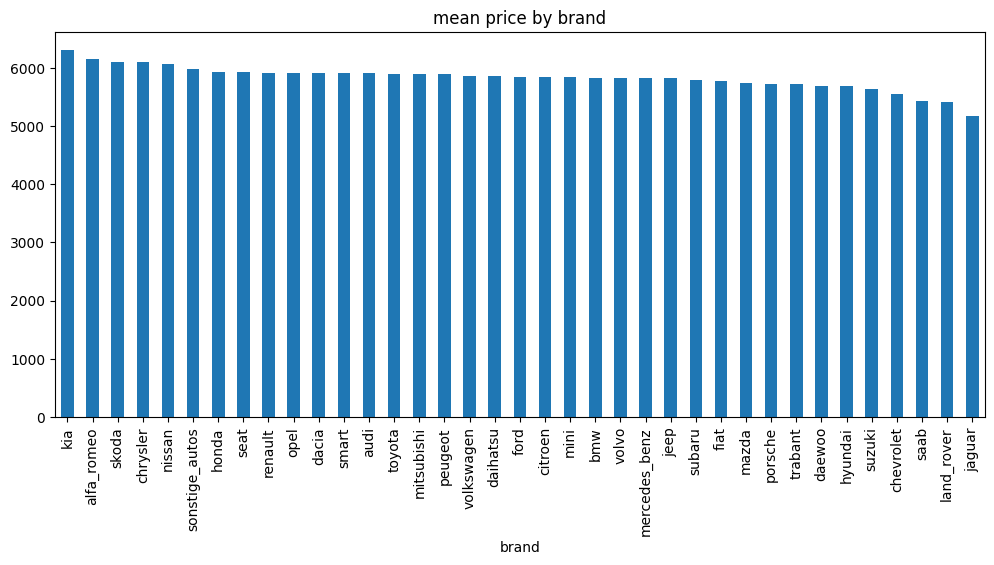

In [149]:
brand_stats = (df.groupby('brand')['price']
                 .agg(['count', 'mean', 'median'])
                 .query('count >= 500')
                 .sort_values('mean', ascending=False))
print(brand_stats)

brand_stats['mean'].plot(kind='bar', figsize=(12, 5), title='mean price by brand')
plt.show()

            count  median         mean
kilometer                             
5000         6257  3200.0  5860.171168
10000        1770  2990.0  5468.749153
20000        5298  3000.0  5719.985466
30000        5657  3000.0  5709.826233
40000        6041  3000.0  5787.474921
50000        7174  3100.0  5877.220100
60000        8209  3000.0  5766.653551
70000        9143  3000.0  5754.108826
80000       10356  3000.0  5916.310062
90000       11727  3200.0  5845.478810
100000      14892  3000.0  5814.726363
125000      35306  3000.0  5846.682632
150000     221757  3100.0  5896.756616


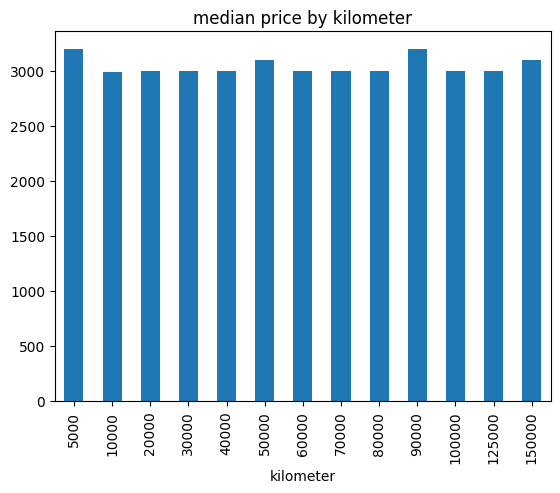

In [150]:
km_stats = df.groupby('kilometer')['price'].agg(['count', 'median', 'mean'])
print(km_stats)

km_stats['median'].plot(kind='bar', title='median price by kilometer')
plt.show()

     count  median
age               
0     9485  3150.0
1     2870  2999.0
2     4595  3100.0
3     5910  3000.0
4     9073  3000.0
..     ...     ...
62      16  2094.5
63      18  2645.0
64      12  2699.5
65      19  1700.0
66      22  4125.0

[67 rows x 2 columns]


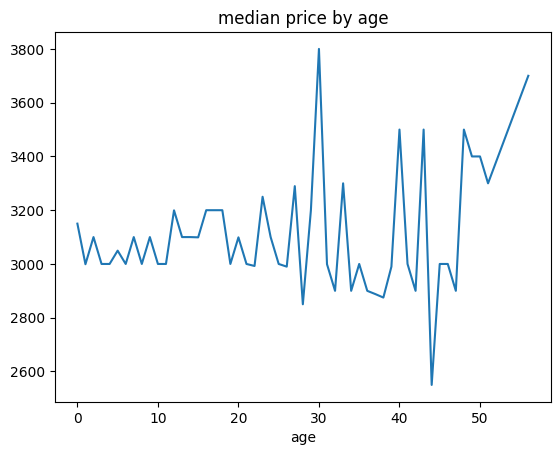

In [151]:
age_stats = df.groupby('age')['price'].agg(['count', 'median'])
print(age_stats)

age_stats.loc[age_stats['count'] >= 100, 'median'].plot(title='median price by age')
plt.show()

In [155]:
df = df[df['year_of_registration'].between(1950, 2016)].copy()
df['age'] = 2016 - df['year_of_registration']
print(df[['price', 'kilometer', 'age']].corr(method='spearman'))

              price  kilometer       age
price      1.000000   0.003734 -0.000023
kilometer  0.003734   1.000000  0.375364
age       -0.000023   0.375364  1.000000


5.

In [156]:
df.groupby('brand')['price'].mean().sort_values(ascending=False)

,price
brand,
kia,6298.507412
alfa_romeo,6157.248626
skoda,6106.441104
chrysler,6091.331121
nissan,6071.786758
lada,6029.961722
sonstige_autos,5978.807960
honda,5932.500769
seat,5932.312716
